# Progetto Introduzione alla Data Science e al pensiero computazionale a.a. 2025-26 - Gruppo 8

Il Gruppo 8 è composto da:
*   **Gaia Gasparini:** matricola n. 1226091, gaia.gasparini@studio.unibo.it
*   **Aurora Paolicchi:** matricola n. 1216261, aurora.paolicchi@studio.unibo.it
*   **Lucrezia Volpato:** matricola n. 1231337, lucrezia.volpato@studio.unibo.it







## **Customer Churn Prediction**

**Obiettivo:** prevedere se un cliente abbandonerà il servizio (churn) sulla base
di informazioni demografiche, contrattuali e di utilizzo del servizio.

**Dataset:** Telco Customer Churn — 7.043 osservazioni, 21 variabili, target: `Churn` (Yes/No)

**Fasi del progetto**:
*   Fase 1: Descrizione e comprensione del dataset
*   Fase 2: Analisi esplorativa e visualizzazione
*   Fase 3: Modellazione
*   Fase 4: Valutazione e interpretazione dei risultati

# Preparazione ambiente

Prima di iniziare dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**, le librerie Python che abbiamo visto in questo corso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carichiamo il dataset

In [2]:
from pandas.core.frame import DataFrame
# Carica il dataset
df = pd.read_csv('sample_data/Customer_Churn.csv')

# Mostra le prime 5 righe per verificare che sia tutto ok
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Fase 1: Descrizione e Composizione del dataset

## D1: Quante osservazioni e variabili contiene il dataset?



In [3]:
# Dimensioni del dataset: numero di osservazioni e variabili
print("Dimensioni del dataset:", df.shape)
print("Il numero di osservazioni del Dataset è:", df.shape[0])
print("Il numero di variabili del Dataset è:", df.shape[1])

Dimensioni del dataset: (7043, 21)
Il numero di osservazioni del Dataset è: 7043
Il numero di variabili del Dataset è: 21


Il dataset è composto da 7.043 osservazioni e 21 variabili.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Il dataset è composto da 21 variabili: 3 numeriche (`tenure`, `MonthlyCharges`) e 18 categoriche, inclusa la variabile target `Churn`. `SeniorCitizen`, pur essendo codificata come intero (0/1), è di natura categorica. `TotalCharges`, pur rappresentando un importo monetario, è codificata come stringa — entrambe le anomalie saranno corrette in fase di preprocessing.

## D2: Esistono valori mancati o Id cliente duplicati?

In [5]:
# Verifica Id duplicati
id_duplicati = df.duplicated(subset=["customerID"]).sum()
print("Ci sono", id_duplicati, "id duplicati.")

Ci sono 0 id duplicati.


In [6]:
# Verifica valori mancanti espliciti (NaN)
print("Valori NaN per colonna:")
print(df.isnull().sum())


Valori NaN per colonna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Valori vuoti nascosti in TotalCharges
print("\nValori vuoti in TotalCharges:", (df['TotalCharges'].str.strip() == '').sum())
print(df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])


Valori vuoti in TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


Non sono presenti `customerID` duplicati.
Il dataset non contiene valori NaN espliciti, tuttavia `TotalCharges` nasconde 11 valori vuoti (" ") non rilevabili con `isnull()`. Tutti e 11 i casi corrispondono a clienti con `tenure = 0`, probabilmente appena acquisiti e senza addebiti registrati.

## D3: Qual è la distribuzione percentuale della variabile churn?



In [8]:
# Distribuzione della variabile target Churn
churn_percentuale = df['Churn'].value_counts(normalize=True) * 100
print(churn_percentuale.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Il dataset presenta un **class imbalance** moderato: il 73.46% dei clienti non ha abbandonato il servizio contro il 26.54% che lo ha fatto (~3:1). Questo squilibrio richiede attenzione nella scelta delle metriche e dell'algoritmo di classificazione

## D4: Come si distribuisce la variabile 'tenure' (numero di mesi di permanenza del cliente)?


In [9]:
# Misure di centralità (media e mediana), deviazione standard e range dei valori della variabile 'tenure'
media_tenure = df["tenure"].mean()
mediana_tenure = df["tenure"].median()
deviazione_standard_tenure = df["tenure"].std()
min_tenure = df["tenure"].min()
max_tenure = df["tenure"].max()
print (f"tenure: media = {media_tenure:.2f}, mediana = {mediana_tenure:.2f}, deviazione standard = {deviazione_standard_tenure:.2f}, min = {min_tenure:.2f}, max = {max_tenure:.2f}")


tenure: media = 32.37, mediana = 29.00, deviazione standard = 24.56, min = 0.00, max = 72.00


La `tenure` ha media pari a **32,4** **mesi** e mediana di **29 mesi**. Le due misure sono relativamente vicine, segno che la permanenza media e quella del cliente "centrale" non divergono in modo marcato. I valori vanno da un minimo di **0** a un massimo di **72 mesi**, con una deviazione standard di **24,6**: una dispersione ampia, che indica clienti molto eterogenei per anzianità, dai nuovissimi a chi è presente da sei anni.

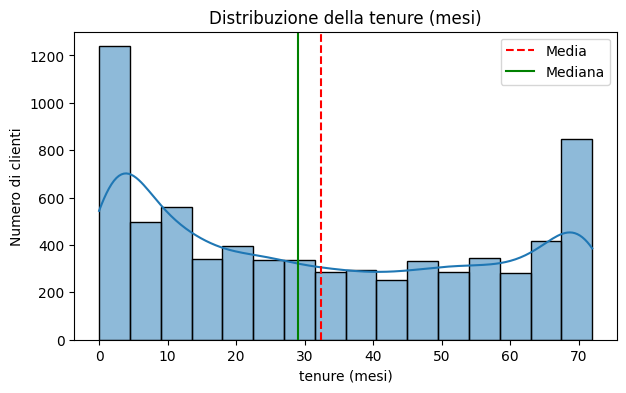

In [10]:
# Visualizziamo graficamente la distribuzione della variabile 'tenure'

plt.figure(figsize=(7, 4))
sns.histplot(df["tenure"], kde=True)
plt.axvline(df["tenure"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["tenure"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione della tenure (mesi)")
plt.xlabel("tenure (mesi)")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

L'istogramma rivela una **distribuzione bimodale**: una forte concentrazione di clienti molto recenti (tenure vicina a 0) e una seconda concentrazione di clienti di lunga data (vicini ai 72 mesi), con la zona centrale meno popolata. Media e mediana cadono proprio in quest'area intermedia, segnalando la presenza di **due gruppi distinti**: nuovi clienti e clienti storici.

## D5: Come si distribuiscono le variabili di spesa MonthlyCharges (canone mensile) e TotalCharges (spesa cumulata)?

In [11]:
# Misure di centralità (media e mediana), deviazione standard e range dei valori della variabile 'Monthly Charges'
media_monthly_charges = df["MonthlyCharges"].mean()
mediana_monthly_charges = df["MonthlyCharges"].median()
deviazione_standard_monthly_charges = df["MonthlyCharges"].std()
min_monthly_charges = df["MonthlyCharges"].min()
max_monthly_charges = df["MonthlyCharges"].max()

# La variabile 'Total Charges' viene letta da pandas come testo e non come numero a causa degli 11 valori vuoti bisogna quindi prima convertirla.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# errors=coerce dice "se trovi un valore che non riesci a convertire (lo spazio vuoto), non bloccarti: trasformalo in NaN"
# Adesso possiamo procedere con i calcoli di media, mediana, deviazione standard e range dei valori
media_total_charges = df["TotalCharges"].mean()
mediana_total_charges = df["TotalCharges"].median()
deviazione_standard_total_charges = df["TotalCharges"].std()
min_total_charges = df["TotalCharges"].min()
max_total_charges = df["TotalCharges"].max()

print(f"MonthlyCharges: media = {media_monthly_charges:.2f}, mediana = {mediana_monthly_charges:.2f}, std = {deviazione_standard_monthly_charges:.2f}, min = {min_monthly_charges:.2f}, max = {max_monthly_charges:.2f}")
print(f"TotalCharges: media = {media_total_charges:.2f}, mediana = {mediana_total_charges:.2f}, std = {deviazione_standard_total_charges:.2f}, min = {min_total_charges:.2f}, max = {max_total_charges:.2f}")



MonthlyCharges: media = 64.76, mediana = 70.35, std = 30.09, min = 18.25, max = 118.75
TotalCharges: media = 2283.30, mediana = 1397.47, std = 2266.77, min = 18.80, max = 8684.80


Per `MonthlyCharges` la media è **64,8** e la mediana **70,4**: la media leggermente inferiore alla mediana suggerisce una possibile asimmetria. I valori si distribuiscono tra **18,3** e **118,8**, con deviazione standard di **30,1**.

Per `TotalCharges` lo scarto è molto più ampio (media **2.283,3** contro mediana **1.397,5**): la media nettamente superiore alla mediana indica che pochi clienti con spesa cumulata elevata alzano il valore medio. Lo confermano l'intervallo molto esteso (da **18,8** a **8.684,8**) e una deviazione standard di **2.266,8**, quasi pari alla media stessa, segnale di una variabilità molto marcata. Questa è un'ipotesi sulla forma delle distribuzioni che verificheremo nella fase di analisi esplorativa.

### Distribuzione di MonthlyCharges

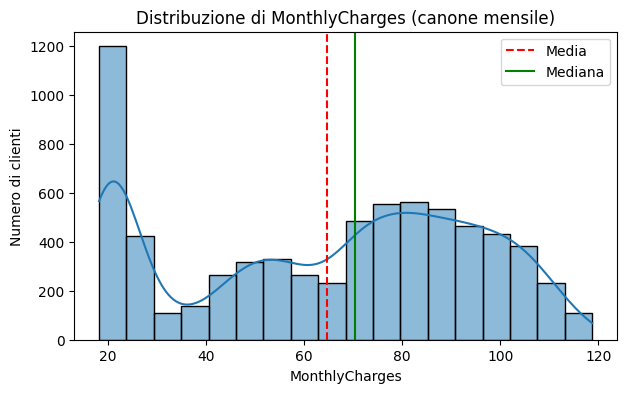

In [12]:
# Visualizziamo graficamente la distribuzione della variabile 'Monthly Charges'

plt.figure(figsize=(7, 4))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.axvline(df["MonthlyCharges"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["MonthlyCharges"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione di MonthlyCharges (canone mensile)")
plt.xlabel("MonthlyCharges")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

Anche in questo caso la distribuzione è **bimodale**: un picco marcato sui valori più bassi (intorno ai 20€) e un'ampia concentrazione sui valori medio-alti (tra 70 e 110€ circa), separati da una fascia intermedia meno densa. Questo suggerisce **due profili di clientela con livelli di servizio differenti**, una struttura che la sola vicinanza tra media e mediana non lasciava prevedere.

###Distribuzione di TotalCharges

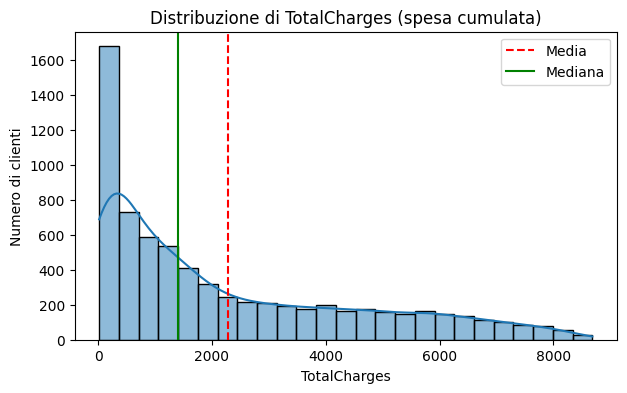

In [13]:
# Visualizziamo graficamente la distribuzione della variabile 'Total Charges'

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
plt.figure(figsize=(7, 4))
sns.histplot(df["TotalCharges"], kde=True)
plt.axvline(df["TotalCharges"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["TotalCharges"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione di TotalCharges (spesa cumulata)")
plt.xlabel("TotalCharges")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

L'istogramma mostra una marcata **asimmetria**: i clienti si concentrano sui valori bassi di spesa cumulata, con una lunga coda verso destra. La linea della media cade visibilmente a destra della mediana: è la rappresentazione grafica dello scarto tra i due valori osservato in precedenza, dovuto ai pochi clienti con spesa molto elevata.

 ## D6: Analizziamo la composizione demografica del campione (variabili genere, SeniorCitizen, partner, dependents)

### Genere

In [14]:
# Conteggio
conteggi_gen = df["gender"].value_counts()
print(conteggi_gen)

# Percentualizzo
totale_clienti = len(df)
percentuale_m = ((conteggi_gen["Male"] / totale_clienti) * 100).round(2)
percentuale_f = ((conteggi_gen["Female"] / totale_clienti) * 100).round(2)

print("La percentuale di maschi è:", percentuale_m)
print("La percentuale di femmine è:", percentuale_f)

gender
Male      3555
Female    3488
Name: count, dtype: int64
La percentuale di maschi è: 50.48
La percentuale di femmine è: 49.52


Il dataset presenta un equilibrio demografico: i clienti di sesso maschile sono il 50.48% e quelli di sesso femminile il 49.52%.

### SeniorCitizen (essere cittadino senior o no)

In [15]:
# Conteggio
conteggi_SenCit = df["SeniorCitizen"].value_counts()
print(conteggi_SenCit)

# Percentualizzo
totale_clienti = len(df)
percentuale_sen = ((conteggi_SenCit[1] / totale_clienti) * 100).round(2)
percentuale_NoSen = ((conteggi_SenCit[0] / totale_clienti) * 100).round(2)

print("La percentuale di cittadini senior è:", percentuale_sen)
print("La percentuale di cittadini non senior è:", percentuale_NoSen)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
La percentuale di cittadini senior è: 16.21
La percentuale di cittadini non senior è: 83.79


Possiamo notare che circa l'84% dei clienti sono cittadini giovani, la percentuale restante sono senior.

### Partner

In [16]:
# Conteggio
conteggi_part = df["Partner"].value_counts()
print(conteggi_part)

# Percentualizzo
totale_clienti = len(df)
percentuale_PYes = ((conteggi_part["Yes"] / totale_clienti) * 100).round(2)
percentuale_PNo = ((conteggi_part["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti con partner è:", percentuale_PYes)
print("La percentuale di clienti senza partner è:", percentuale_PNo)

Partner
No     3641
Yes    3402
Name: count, dtype: int64
La percentuale di clienti con partner è: 48.3
La percentuale di clienti senza partner è: 51.7


Possiamo notare che le due categorie differiscono di pochi punti percentuali, circa metà dei clienti ha un partner e l'altra metà non ce l'ha.

###Dependents (avere una persona a carico o no)

In [17]:
# Conteggio
conteggi_dep = df["Dependents"].value_counts()
print(conteggi_dep)

# Percentualizzo
totale_clienti = len(df)
percentuale_DYes = ((conteggi_dep["Yes"] / totale_clienti) * 100).round(2)
percentuale_DNo = ((conteggi_dep["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti con persone a carico è:", percentuale_DYes)
print("La percentuale di clienti senza persone a carico è:", percentuale_DNo)

Dependents
No     4933
Yes    2110
Name: count, dtype: int64
La percentuale di clienti con persone a carico è: 29.96
La percentuale di clienti senza persone a carico è: 70.04


Notiamo che il 70% dei clienti non hanno persone a carico, a fronte di un 30% di clienti che le ha.

## D7: Come sono distribuiti i servizi di rete? (PhoneService, MultipleLines e InternetService)

### Phone Service

In [18]:
# Conteggio
conteggi_phone = df["PhoneService"].value_counts()
print(conteggi_phone)

# Percentualizzo
totale_clienti = len(df)
percentuale_PhYes = ((conteggi_phone["Yes"] / totale_clienti) * 100).round(2)
percentuale_PhNo = ((conteggi_phone["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti hanno un Phone Service è:", percentuale_PhYes)
print("La percentuale di clienti senza un Phone Service è:", percentuale_PhNo)

PhoneService
Yes    6361
No      682
Name: count, dtype: int64
La percentuale di clienti hanno un Phone Service è: 90.32
La percentuale di clienti senza un Phone Service è: 9.68


Si può notare che il 90% dei clienti hanno un Phone Service.

### Multiple Lines

In [19]:
# Conteggio
conteggi_lines = df["MultipleLines"].value_counts()
print(conteggi_lines)

# Percentualizzo
totale_clienti = len(df)
percentuale_no_lines = ((conteggi_lines["No"] / totale_clienti) * 100).round(2)
percentuale_si_lines = ((conteggi_lines["Yes"] / totale_clienti) * 100).round(2)
# La percentuale dei clienti senza un phone service l'abbiamo già calcolata prima
percentuale_PhNo = ((conteggi_phone["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti che non ha linee multiple è:", percentuale_no_lines)
print("La percentuale di clienti che ha linee multiple è:", percentuale_si_lines)
print("La percentuale di No phone service è:", percentuale_PhNo)

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
La percentuale di clienti che non ha linee multiple è: 48.13
La percentuale di clienti che ha linee multiple è: 42.18
La percentuale di No phone service è: 9.68


Tra i clienti che possiedono una linea telefonica, circa il 42% ha attivato l'opzione delle linee multiple, mentre il 48% mantiene una linea singola. Una piccola fetta di clienti (circa il 10%) non ha un servizio telefonico.

### Internet Service

In [20]:
# Conteggio
conteggi_IntSer = df["InternetService"].value_counts()
print(conteggi_IntSer)

# Percentualizzo
totale_clienti = len(df)
percentuale_DSL = ((conteggi_IntSer["DSL"] / totale_clienti) * 100).round(2)
percentuale_Fiber = ((conteggi_IntSer["Fiber optic"] / totale_clienti) * 100).round(2)
percentuale_NoIntSer = ((conteggi_IntSer["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti che hanno un servizio internet DSL è:", percentuale_DSL)
print("La percentuale di clienti che hanno un servizio internet Fiber optic è:", percentuale_Fiber)
print("La percentuale di clienti senza un servizio internet è:", percentuale_NoIntSer)

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
La percentuale di clienti che hanno un servizio internet DSL è: 34.37
La percentuale di clienti che hanno un servizio internet Fiber optic è: 43.96
La percentuale di clienti senza un servizio internet è: 21.67


Circa il 34% dei clienti ha un servizio internet DSL, il 44% un servizio di fibra ottica e il 22% non ha un servizio internet.

Per visualizzare meglio la distribuzione della tipologia di Internet Service possiamo fare un grafico a barre:

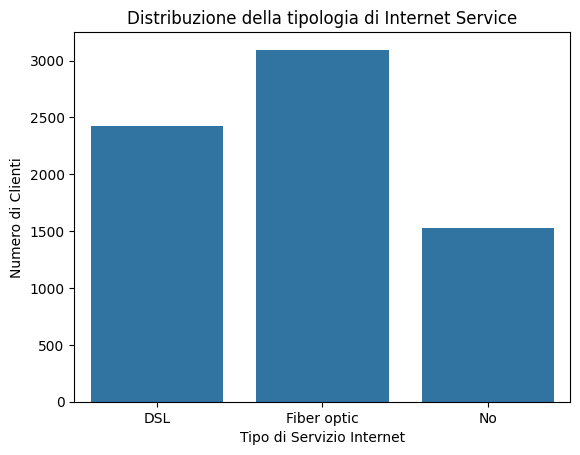

In [21]:
# Grafico per la distribuzione del servizio Internet
sns.countplot(data=df, x="InternetService")
plt.title("Distribuzione della tipologia di Internet Service")
plt.xlabel("Tipo di Servizio Internet")
plt.ylabel("Numero di Clienti")
plt.show()

Qui è evidente che la maggior parte dei clineti hanno un servizio di Fiber Optic.

## D8: Come si distribuiscono le variabili dei servizi di supporto e intrattenimento?

### Online Security, Online Backup, Device Protection, Tech Support, StreamingTV, Streaming Movies

In [22]:
# 1. Creiamo una lista con tutti i servizi aggiuntivi che vogliamo analizzare
servizi_aggiuntivi = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# totale clienti
totale_clienti = len(df)

# 2. Facciamo partire il ciclo che esamina un servizio alla volta
for servizio in servizi_aggiuntivi:

    print(f"\n ANALISI SERVIZIO: {servizio} ")

    # Conteggio per il servizio corrente
    conteggi = df[servizio].value_counts()
    print(conteggi)

    # Calcolo delle percentuali
    percentuale_no = ((conteggi["No"] / totale_clienti) * 100).round(2)
    percentuale_si = ((conteggi["Yes"] / totale_clienti) * 100).round(2)
    percentuale_no_internet = ((conteggi["No internet service"] / totale_clienti) * 100).round(2)

    # Stampiamo i risultati
    print(f"La percentuale di No è: {percentuale_no}%")
    print(f"La percentuale di Yes è: {percentuale_si}%")
    print(f"La percentuale di No internet service è: {percentuale_no_internet}%")


 ANALISI SERVIZIO: OnlineSecurity 
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 49.67%
La percentuale di Yes è: 28.67%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: OnlineBackup 
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 43.84%
La percentuale di Yes è: 34.49%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: DeviceProtection 
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 43.94%
La percentuale di Yes è: 34.39%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: TechSupport 
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 49.31

Per ogni servizio teniamo a mente che, come abbiamo visto in precedenza, il 21.67% dei clienti non ha un servizio internet.

ONLINE SECURITY: Si nota che circa il 50% dei clienti ha un abbonamento senza online security, a fronte di un 29% di clienti con online security. La percentuale di clienti senza un servizio internet rimane circa il 22% come già calcolato.

ONLINE BACKUP: Il 44% dei clienti non ha un servizio di backup online, a fronte di un 34% che lo ha.

DEVICE PROTECTION: Il 44% non ha una device protection, a fronte di un 34% che ce l'ha.

TECH SUPPORT: il 50% dei clienti gode di supporto tecnico, mentre il 30% no.

STREAMING TV: Il 40% dei clienti ha un abbonamento a servizi di streaming TV, mentre un restante 40% non ha questo tipo di abbonamento.

STREAMING MOVIES: Il 40% dei clienti ha un abbonamento a servizi di streaming Movies, mentre un restante 40% non ha questo tipo di abbonamento.

## D9: Distribuzione delle modalità di fatturazione e dei vincoli contrattuali

### Metodo di pagamento

In [23]:
# Conteggio
conteggi_pagamento = df["PaymentMethod"].value_counts()
print(conteggi_pagamento)

# Percentualizzo
percentuale_electronic = ((conteggi_pagamento["Electronic check"] / totale_clienti) * 100).round(2)
percentuale_mailed = ((conteggi_pagamento["Mailed check"] / totale_clienti) * 100).round(2)
percentuale_bank = ((conteggi_pagamento["Bank transfer (automatic)"] / totale_clienti) * 100).round(2)
percentuale_credit = ((conteggi_pagamento["Credit card (automatic)"] / totale_clienti) * 100).round(2)

# Risultati
print("La percentuale di clienti che utilizza l'Electronic check è:", percentuale_electronic)
print("La percentuale di clienti che utilizza il Mailed check è:", percentuale_mailed)
print("La percentuale di clienti che utilizza il Bank transfer (automatic) è:", percentuale_bank)
print("La percentuale di clienti che utilizza la Credit card (automatic) è:", percentuale_credit)

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
La percentuale di clienti che utilizza l'Electronic check è: 33.58
La percentuale di clienti che utilizza il Mailed check è: 22.89
La percentuale di clienti che utilizza il Bank transfer (automatic) è: 21.92
La percentuale di clienti che utilizza la Credit card (automatic) è: 21.61


- L'electronick check è il metodo di pagamento più utilizzato, scelto da oltre un terzo dei clienti (33.58%)

- I metodi di pagamento automatici (Back transfer e la Credit Card) sono utilizzati da due fette di clienti, ciascuna delle quali rappresenta circa il 22% dei clienti.

- Il metodo di pagamento più tradizionale, ovvero il mailed check, è utilizzato dal 23% dei clienti.

### Tipo di contratto

In [24]:
# Conteggio
conteggi_contratto = df["Contract"].value_counts()
print(conteggi_contratto)

# Percentualizzo
percentuale_mese = ((conteggi_contratto["Month-to-month"] / totale_clienti) * 100).round(2)
percentuale_anno = ((conteggi_contratto["One year"] / totale_clienti) * 100).round(2)
percentuale_biennio = ((conteggi_contratto["Two year"] / totale_clienti) * 100).round(2)

# Risultati
print("La percentuale di clienti che scelgono un contratto Mese per Mese è:", percentuale_mese)
print("La percentuale di clienti che scelgono un contratto Annuale è:", percentuale_anno)
print("La percentuale di clienti che scelgono un contratto Biennale è:", percentuale_biennio)

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
La percentuale di clienti che scelgono un contratto Mese per Mese è: 55.02
La percentuale di clienti che scelgono un contratto Annuale è: 20.91
La percentuale di clienti che scelgono un contratto Biennale è: 24.07


- La metà dei clienti (55%) scelgono un contratto che si rinnova mese per mese

- Il 21% dei clienti ha scelto un contratto Annuale e il 24% dei clienti ha scelto un contratto Biennale

Nel seguende grafico possiamo mostrare la grande sproporzione tra chi sceglie un contratto mese per mese e chi sceglie un contratto di uno o due anni:

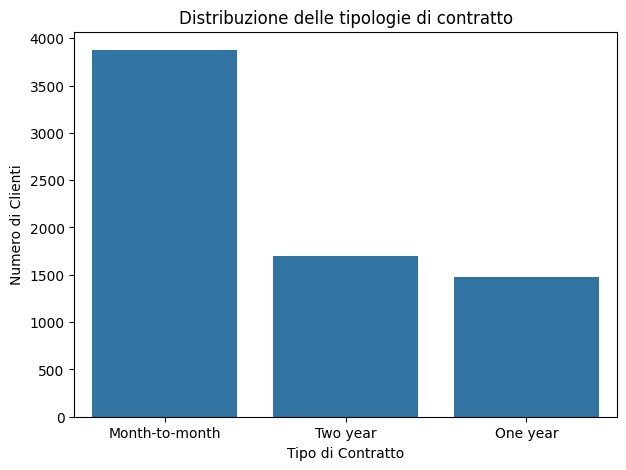

In [25]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", order=df["Contract"].value_counts().index)

plt.title("Distribuzione delle tipologie di contratto")
plt.xlabel("Tipo di Contratto")
plt.ylabel("Numero di Clienti")

plt.show()

#Fase 2:  Analisi esplorativa e visualizzazione

## D1: I clienti con contratto mensile abbandonano maggiormente?

Ipotesi: i contratti Month-to-month presentano un tasso di churn nettamente superiore rispetto ai contratti annuali e biennali.

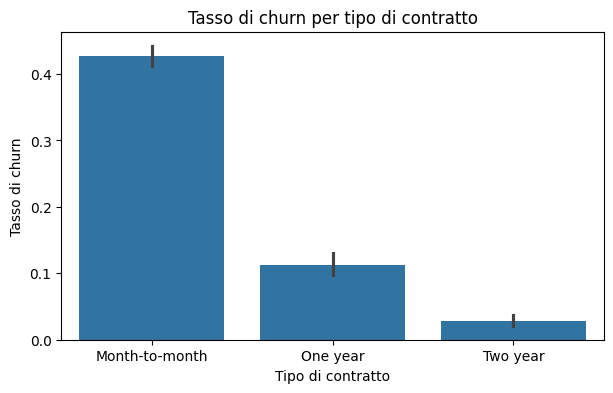

In [26]:
# Convertiamo Churn (testo "Yes"/"No") in numerico (1/0):
# "Yes" -> True -> 1, "No" -> False -> 0.
# ci permette di calcolare il tasso di churn per gruppo.
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="Contract", y="Churn_num")
plt.title("Tasso di churn per tipo di contratto")
plt.xlabel("Tipo di contratto")
plt.ylabel("Tasso di churn")
plt.show()

Il barplot conferma l'ipotesi: il tasso di churn dei contratti *Month-to-month* è nettamente più alto, attorno al **40%**, mentre scende a circa il **10%** per i *contratti annuali* e a **pochi punti percentuali** per i *biennali*.
La durata del contratto risulta quindi fortemente associata all'abbandono: i clienti senza vincolo temporale abbandonano molto più spesso.

## D2:  Come si distribuisce la variabile 'tenure' tra chi abbandona e chi resta?

Ipotesi: i clienti che abbandonano hanno un'anzianità inferiore, ovvero tendono a lasciare il servizio nei primi mesi.

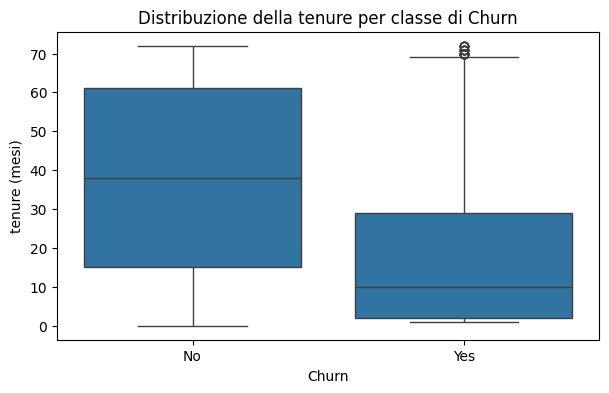

In [27]:
# Boxplot della tenure separata per classe di Churn
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Distribuzione della tenure per classe di Churn")
plt.xlabel("Churn")
plt.ylabel("tenure (mesi)")
plt.show()

Il boxplot conferma con chiarezza l'ipotesi: la distribuzione della tenure di chi abbandona è interamente spostata verso il basso rispetto a chi resta. I clienti che fanno churn hanno una tenure mediana di circa **10 mesi**, contro i circa **38 mesi** di chi rimane, e anche la loro metà centrale si concentra nei primi mesi di rapporto. L'abbandono si verifica quindi soprattutto all'inizio della relazione con l'azienda. Si nota inoltre un piccolo gruppo di clienti con tenure elevata che abbandonano comunque (valori anomali nel gruppo "Yes"): un'eccezione che potrebbe meritare un approfondimento. Il risultato conferma quanto emerso nella fase descrittiva: gran parte dei clienti che abbandonano si trova tra quelli con pochi mesi di anzianità.

## D3: Le variabili di spesa sono correlate tra loro e con tenure?

Ipotesi: `TotalCharges` è fortemente correlata sia con `tenure` sia con `MonthlyCharges`, confermando la ridondanza individuata nella fase di comprensione del dataset.

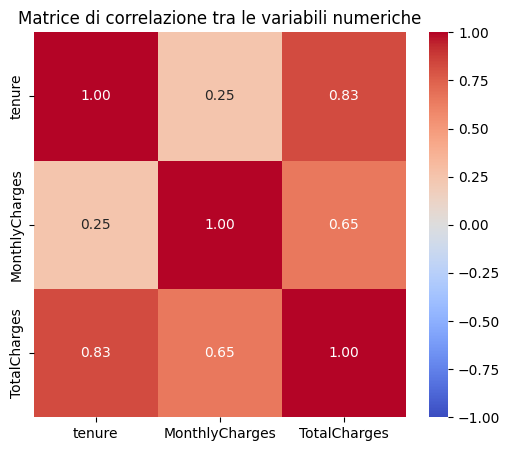

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Selezioniamo solo le variabili numeriche di interesse
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[num_cols].corr()   # calcola la matrice di correlazione

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice di correlazione tra le variabili numeriche")
plt.show()

La heatmap conferma l'ipotesi e mostra la ridondanza già notata nella fase di descrizione del dataset. `TotalCharges` è molto legata a `tenure` (**0,83**) e abbastanza a` MonthlyCharges `(**0,65**), mentre `tenure` e `MonthlyCharges` hanno poco a che fare l'una con l'altra (**0,25**). Il motivo è intuitivo: la spesa totale dipende da quanti mesi il cliente è rimasto e da quanto paga ogni mese, quindi racchiude in sé l'informazione delle altre due variabili. In fase di modellazione sarà bene tenerne conto, valutando se usare tutte e tre le variabili o eliminarne una per evitare di ripetere la stessa informazione.